# <span style="color:orange;">Barreras a la formación</span>

<span style="font-size:15px; color:green;"><b>Encuesta Anual Laboral (EAL) 2022–2024 · Sector Transporte y almacenamiento (proxy: Servicios)</b></span>

**Fuente:** Encuesta Anual Laboral, Ministerio de Trabajo y Economía Social
**Pregunta de negocio:** ¿Cómo podríamos ajustar nuestras políticas de formación para alinearlas con las tendencias formativas del sector, en cuanto a competencias clave, medios utilizados y barreras más comunes, para aumentar el impacto del desarrollo profesional en la organización?

**Alcance de este notebook:** el módulo de **barreras** (hojas EAL-24 "empresas formadoras" y EAL-25 "empresas no formadoras"), para los años 2022, 2023 y 2024.

---

# 1. Objetivos

### Objetivo general
Analizar la evolución de las barreras a la formación en España entre 2022 y 2024 para identificar oportunidades de mejora en las políticas de formación empresarial.

### Objetivos específicos

- Identificar cuáles son las barreras más frecuentes para participar en acciones formativas.
- Analizar la evolución temporal de cada barrera entre 2022 y 2024, tanto a nivel de motivo individual como de dimensión estratégica.
- Evaluar si las diferencias observadas (entre años, y entre grupos) son estadísticamente significativas.
- Comparar los resultados obtenidos con las tendencias generales del sector.
- Pasar de hallazgos a recomendaciones para el dpt. de RRHH para mejorar el acceso y el impacto de la formación.

---
### Preguntas que responde este notebook

1. ¿Qué barreras son las más frecuentes, y cuáles son más relevantes o crecen más?
2. ¿Cómo han evolucionado entre 2022 y 2024, por motivo y por dimensión estratégica?
3. ¿Qué cambios y diferencias son estadísticamente significativos?
4. ¿Qué implicaciones tienen estos resultados para el diseño de políticas de formación?

---
## Metodología del análisis

1. **Análisis exploratorio (EDA)** — Se describen las principales barreras a la formación mediante estadísticas descriptivas y visualizaciones para identificar patrones generales.
2. **Evolución temporal** — Se comparan los resultados de 2022, 2023 y 2024, por motivo individual y por dimensión estratégica agregada.
3. **Contraste estadístico** — Las diferencias (entre años y entre grupos) se evalúan mediante pruebas de comparación de proporciones (z-test), α = 0,05.
4. **Benchmark** — Servicios vs. Total nacional, y Formadoras vs. No formadoras, con su significación estadística correspondiente.

El objetivo final es transformar los resultados estadísticos en recomendaciones para Recursos Humanos que ayuden a reducir las barreras a la formación.

**Un resultado destacado se muestra en la sección 4, justo después de la limpieza de datos — el resto del notebook es el trabajo que lo sustenta.**

---
#### Nota sobre los datos de origen

Las hojas EAL-24 y EAL-25 preguntan, respectivamente, a empresas que **sí** formaron y que **no** formaron a sus trabajadores, cuánto limitó (EAL-24) o influyó (EAL-25) cada uno de una serie de motivos, en una escala Nada/Poco/Bastante/Mucho.

Ninguna de las dos hojas publica el dato exacto para "Transporte y almacenamiento"; el nivel de publicación más fino disponible es el bloque **Sector Servicios**, que se usa aquí como proxy explícito.

## 1.1 Imports

In [80]:
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.gridspec import GridSpec
import plotly.express as px

from statsmodels.stats.proportion import proportions_ztest
import openpyxl

---
## 2. Extracción de datos

Cada hoja (`EAL-24`, `EAL-25`) apila varias subtablas idénticas en estructura (mismos motivos, mismas columnas Nada/Poco/Bastante/Mucho) para distintos recortes: total nacional, tramos de tamaño, e Industria/Construcción/Servicios. No hay una fila fija: la posición cambia ligeramente de un año a otro, así que se localizan los bloques buscando el texto que los identifica, no un número de fila.

`extraer_bloque()` busca la etiqueta de inicio del bloque (p. ej. `"SECTOR SERVICIOS"`), localiza la fila de cabecera (`TOTAL / NADA / POCO / BASTANTE / MUCHO`) y lee los motivos hasta encontrar el siguiente bloque (`EAL-...`) o el final de la tabla.

In [81]:
RUTA_DATOS = r"..\Data\Encuesta_EAL\Raw_2022-2024"

RUTA_ARCHIVOS = {
    2022: fr"{RUTA_DATOS}\Tablas_EAL_2022.xlsx",
    2023: fr"{RUTA_DATOS}\Tablas_EAL_2023.xlsx",
    2024: fr"{RUTA_DATOS}\Tablas_EAL_2024.xlsx",
}

HOJAS = {"EAL-24": "Formadoras", "EAL-25": "No_formadoras"}


def leer_filas(ruta, hoja):
    '''Lee una hoja completa como lista de tuplas (una por fila).'''
    libro = openpyxl.load_workbook(ruta, read_only=True, data_only=True)
    return list(libro[hoja].iter_rows(values_only=True))


def extraer_bloque(filas, etiqueta_inicio):
    '''Extrae los motivos y sus porcentajes (Nada/Poco/Bastante/Mucho) de un
    bloque identificado por su etiqueta de inicio (p. ej. "SECTOR SERVICIOS").'''
    idx_inicio = next(
        (i for i, fila in enumerate(filas)
         if fila and isinstance(fila[0], str) and etiqueta_inicio in fila[0]),
        None,
    )
    if idx_inicio is None:
        return None

    idx_header = next(
        (i for i in range(idx_inicio, min(idx_inicio + 10, len(filas)))
         if len(filas[i]) > 2 and filas[i][1] == "TOTAL" and filas[i][2] == "NADA"),
        None,
    )
    if idx_header is None:
        return None

    motivos = []
    for fila in filas[idx_header + 1:]:
        primera = fila[0] if fila else None
        if primera is None:
            break
        if isinstance(primera, str) and primera.strip().startswith("EAL-"):
            break
        if len(fila) < 6 or fila[1] is None:
            continue
        motivos.append({
            "motivo_original": primera.strip(),
            "total": fila[1], "nada": fila[2], "poco": fila[3],
            "bastante": fila[4], "mucho": fila[5],
        })
    return motivos

In [82]:
registros = []
avisos_extraccion = []

for anio, ruta in RUTA_ARCHIVOS.items():
    for hoja, tipo_empresa in HOJAS.items():
        filas = leer_filas(ruta, hoja)
        bloques_buscados = [(f"{hoja}.", "Total_Nacional"), ("SECTOR SERVICIOS", "Servicios")]

        for etiqueta, ambito in bloques_buscados:
            bloque = extraer_bloque(filas, etiqueta)
            if bloque is None:
                avisos_extraccion.append(f"{anio} | {hoja} | {ambito}: bloque no encontrado")
                continue
            for motivo in bloque:
                registros.append({"anio": anio, "tipo_empresa": tipo_empresa, "ambito": ambito, **motivo})

df_barreras = pd.DataFrame(registros)

print(f"Registros extraídos: {len(df_barreras)}")
if avisos_extraccion:
    print("Avisos:")
    for aviso in avisos_extraccion:
        print(" -", aviso)

df_barreras.head()

Registros extraídos: 118


,anio,tipo_empresa,ambito,motivo_original,total,nada,poco,bastante,mucho
0,2022,Formadoras,Total_Nacional,El nivel de formación de los empleados era el ...,100,6.678,18.954,58.916,15.452
1,2022,Formadoras,Total_Nacional,La estrategia preferida de la empresa fue cont...,100,18.231,28.405,42.455,10.910
2,2022,Formadoras,Total_Nacional,Dificultad para evaluar la necesidades de form...,100,26.082,57.363,14.480,2.075
3,2022,Formadoras,Total_Nacional,La falta de cursos de formación adecuados en e...,100,22.951,47.662,23.214,6.173
4,2022,Formadoras,Total_Nacional,El alto coste de los cursos de formación,100,17.484,38.316,32.390,11.810


---
## 3. Limpieza y validación

### 3.1 Incidencias detectadas en la fuente

- **Fila duplicada dentro de un mismo bloque:** en 2023, `EAL-25` (no formadoras), Servicios, la fila *"Otras razones"* tiene exactamente los mismos cuatro valores que la fila *"...contratos formativos... dual"* justo encima (68,273 / 20,547 / 9,086 / 2,094). Se ha comprobado que ya está así en el archivo fuente del Ministerio. Se marca como valor sospechoso en la sección 3.3.
- **Motivo no disponible en todos los años:** `Preferencia_Contrato_Formativo_Dual` no está presente para empresas formadoras en 2022 (sí a partir de 2023). Se excluye de los cálculos que promedian varios años para ese grupo, en vez de tratarlo como 0 (sección 5.2).

### 3.2 Igualar los motivos entre años

El mismo motivo se redacta de forma distinta según el año (p. ej. *"La estrategia preferida de la empresa fue contratar personal..."* en 2022 frente a *"La empresa prefirió contratar a personal..."* en 2023). Sin armonizar, la serie temporal se rompería en cada motivo. Se normaliza por palabras clave a un código estable.

In [83]:
REGLAS_NORMALIZACION = [
    ("Nivel_Formacion_Adecuado", ["nivel de formaci", "apropiado"]),
    ("Preferencia_Contratar_Cualificados", ["contratar", "cualificaci"]),
    ("Dificultad_Evaluar_Necesidades", ["dificultad para evaluar"]),
    ("Falta_Cursos_Adecuados", ["falta de cursos"]),
    ("Alto_Coste_Cursos", ["alto coste"]),
    ("Preferencia_Contrato_Formativo_Dual", ["contrato de formaci", "contratos formativos", "dual"]),
    ("Esfuerzo_Previo_Suficiente", ["mayor esfuerzo realizado"]),
    ("Carga_Trabajo_Tiempo", ["carga de trabajo", "tiempo disponible"]),
    ("Dificultad_Ayudas_Subvenciones", ["ayudas o subvenciones"]),
    ("Cancelacion_COVID", ["covid"]),
    ("Otras_Razones", ["otras razones"]),
]


def normalizar_motivo(texto):
    '''Asigna un código estable a cada motivo, por coincidencia de palabras
    clave, para poder comparar entre años pese a cambios de redacción.'''
    texto_normalizado = texto.lower()
    for codigo, palabras_clave in REGLAS_NORMALIZACION:
        if any(palabra in texto_normalizado for palabra in palabras_clave):
            return codigo
    return "OTRO_NO_MAPEADO"


df_barreras["motivo"] = df_barreras["motivo_original"].apply(normalizar_motivo)
df_barreras["bastante_mucho"] = df_barreras["bastante"] + df_barreras["mucho"]

sin_mapear = df_barreras.loc[df_barreras["motivo"] == "OTRO_NO_MAPEADO", "motivo_original"].unique()
print(f"Motivos sin mapear: {len(sin_mapear)}")
for texto in sin_mapear:
    print(" -", texto)

Motivos sin mapear: 0


### 3.3 Validación de consistencia

Cada fila debe sumar (aproximadamente) 100 entre Nada+Poco+Bastante+Mucho.

In [84]:
df_barreras["suma_validacion"] = (
    df_barreras["nada"] + df_barreras["poco"] + df_barreras["bastante"] + df_barreras["mucho"]
)
fuera_de_rango = df_barreras[(df_barreras["suma_validacion"] < 99).to_numpy() | (df_barreras["suma_validacion"] > 101).to_numpy()]

print(f"Filas con suma fuera de [99, 101]: {len(fuera_de_rango)}")

# Detección de filas duplicadas DENTRO de un mismo bloque (mismo año/tipo_empresa/ambito):
columnas_valor = ["nada", "poco", "bastante", "mucho"]
df_barreras["fila_duplicada_en_bloque"] = (
    df_barreras
    .groupby(["anio", "tipo_empresa", "ambito"])[columnas_valor]
    .transform(lambda serie: serie.duplicated(keep=False))
    .all(axis=1)
)

duplicados = df_barreras[df_barreras["fila_duplicada_en_bloque"]]
print(f"\nFilas con valores duplicados dentro de su propio bloque: {len(duplicados)}")
if len(duplicados):
    print(duplicados[["anio", "tipo_empresa", "ambito", "motivo", "bastante_mucho"]].to_string(index=False))

Filas con suma fuera de [99, 101]: 0

Filas con valores duplicados dentro de su propio bloque: 2
 anio  tipo_empresa    ambito                              motivo  bastante_mucho
 2023 No_formadoras Servicios Preferencia_Contrato_Formativo_Dual           11.18
 2023 No_formadoras Servicios                       Otras_Razones           11.18


**Conclusión de la validación:** todas las filas cumplen la suma esperada (~100).
La detección de filas duplicadas confirma el caso documentado en 3.1 ("Otras razones" 2023, no formadoras, Servicios); ese valor concreto se trata como no fiable en la interpretación, sin eliminarlo del dataset.

---
## 4. Resultado principal

Antes de entrar en el detalle estadístico (secciones 5-7), esta es la respuesta directa a "¿qué barreras pesan más y cómo han evolucionado?": la barrera principal para las empresas que ya forman, y cómo se mueven las 5 barreras más relevantes entre 2022 y 2024.

In [85]:
NOMBRES_MOTIVO_CORTO = {
    "Nivel_Formacion_Adecuado": "Nivel adecuado",
    "Esfuerzo_Previo_Suficiente": "Esfuerzo previo suficiente",
    "Preferencia_Contratar_Cualificados": "Contratar ya cualificados",
    "Preferencia_Contrato_Formativo_Dual": "Contrato formativo/dual",
    "Carga_Trabajo_Tiempo": "Carga de trabajo/tiempo",
    "Dificultad_Evaluar_Necesidades": "Dificultad evaluar necesidades",
    "Alto_Coste_Cursos": "Alto coste cursos",
    "Falta_Cursos_Adecuados": "Falta cursos adecuados",
    "Dificultad_Ayudas_Subvenciones": "Dificultad ayudas/subvenciones",
    "Otras_Razones": "Otras razones",
    "Cancelacion_COVID": "Cancelación COVID",
}

COLOR_DESTACADO = "#E8622C"
COLOR_SECUNDARIO = "#2E75B6"
COLOR_NO_SIG = "#C9CDD3"
COLOR_TEXTO = "#22262B"
COLOR_TITULO = "#1B2A38"
COLOR_FONDO = "#FFFFFF"

AÑO_REFERENCIA = 2024


def separar_etiquetas(valores, separacion_minima):
    '''Ajusta un conjunto de posiciones Y para que ninguna etiqueta quede a
    menos de separacion_minima de la siguiente, preservando el orden.'''
    orden = np.argsort(valores)
    ajustadas = np.array(valores, dtype=float)
    for i in range(1, len(orden)):
        actual, anterior = orden[i], orden[i - 1]
        if ajustadas[actual] - ajustadas[anterior] < separacion_minima:
            ajustadas[actual] = ajustadas[anterior] + separacion_minima
    return ajustadas

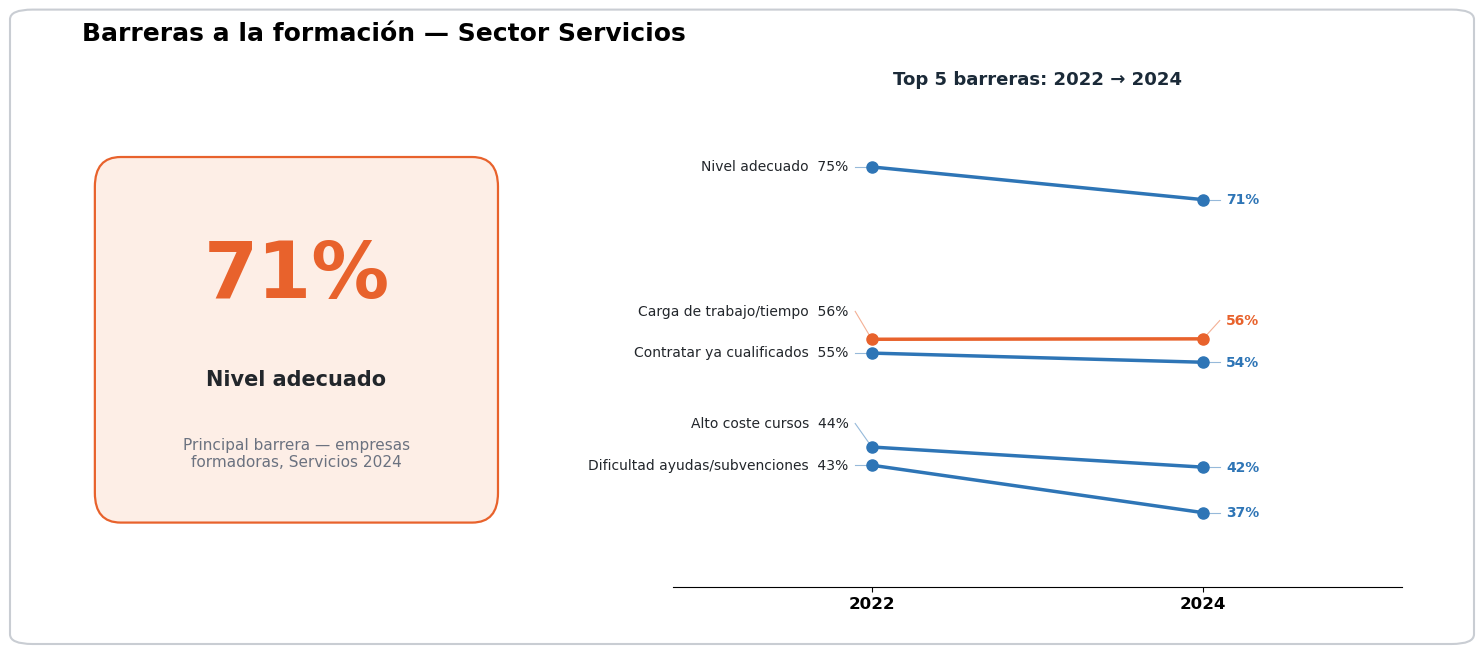

In [86]:
datos_referencia = df_barreras[
    (df_barreras["anio"] == AÑO_REFERENCIA) & (df_barreras["ambito"] == "Servicios")
]

tabla_comparativa = (
    datos_referencia
    .pivot_table(index="motivo", columns="tipo_empresa", values="bastante_mucho")
    .rename(columns={"Formadoras": "Formadoras (%)", "No_formadoras": "No formadoras (%)"})
)
tabla_comparativa["Diferencia (pp)"] = (
    tabla_comparativa["Formadoras (%)"] - tabla_comparativa["No formadoras (%)"]
)
tabla_comparativa = tabla_comparativa.round(1)

datos_hero = (
    datos_referencia[datos_referencia["tipo_empresa"] == "Formadoras"]
    .sort_values("bastante_mucho", ascending=False)
)
motivo_principal = datos_hero.iloc[0]
top5_motivos = datos_hero.head(5)["motivo"].tolist()

# ---- Figura compuesta: callout + slope chart ----
fig = plt.figure(figsize=(15, 6.5))
fig.patch.set_facecolor(COLOR_FONDO)

margen_marco = 0.012
marco = FancyBboxPatch(
    (margen_marco, margen_marco), 1 - 2 * margen_marco, 1 - 2 * margen_marco,
    boxstyle="round,pad=0,rounding_size=0.015", transform=fig.transFigure,
    facecolor=COLOR_FONDO, edgecolor="#C9CDD3", linewidth=1.5, zorder=-10,
)
fig.add_artist(marco)

gs = GridSpec(1, 2, width_ratios=[1, 1.7], figure=fig, left=0.06, right=0.94, top=0.86, bottom=0.10, wspace=0.28)
ax_callout = fig.add_subplot(gs[0, 0])
ax_slope = fig.add_subplot(gs[0, 1])

# --- Panel izquierdo: callout ---
ax_callout.axis("off")
caja = FancyBboxPatch(
    (0.05, 0.15), 0.9, 0.7, boxstyle="round,pad=0.02,rounding_size=0.06",
    transform=ax_callout.transAxes, facecolor="#FDEEE6", edgecolor=COLOR_DESTACADO, linewidth=1.6,
)
ax_callout.add_patch(caja)
ax_callout.text(0.5, 0.63, f"{motivo_principal['bastante_mucho']:.0f}%", transform=ax_callout.transAxes,
                ha="center", va="center", fontsize=56, fontweight="bold", color=COLOR_DESTACADO)
nombre_corto = NOMBRES_MOTIVO_CORTO.get(motivo_principal["motivo"], motivo_principal["motivo"])
ax_callout.text(0.5, 0.42, nombre_corto, transform=ax_callout.transAxes,
                ha="center", va="center", fontsize=15, fontweight="bold", color=COLOR_TEXTO)
ax_callout.text(0.5, 0.27, f"Principal barrera — empresas\nformadoras, Servicios {AÑO_REFERENCIA}",
                transform=ax_callout.transAxes, ha="center", va="center", fontsize=11, color="#6B7280")

# --- Panel derecho: slope chart ---
datos_slope = []
for motivo in top5_motivos:
    v0 = df_barreras[
        (df_barreras["anio"] == 2022) & (df_barreras["ambito"] == "Servicios")
        & (df_barreras["tipo_empresa"] == "Formadoras") & (df_barreras["motivo"] == motivo)
    ]["bastante_mucho"]
    v1 = df_barreras[
        (df_barreras["anio"] == AÑO_REFERENCIA) & (df_barreras["ambito"] == "Servicios")
        & (df_barreras["tipo_empresa"] == "Formadoras") & (df_barreras["motivo"] == motivo)
    ]["bastante_mucho"]
    if v0.empty or v1.empty:
        continue
    datos_slope.append((motivo, v0.iloc[0], v1.iloc[0]))

valores_v0 = [d[1] for d in datos_slope]
valores_v1 = [d[2] for d in datos_slope]
etiquetas_y0 = separar_etiquetas(valores_v0, separacion_minima=4.5)
etiquetas_y1 = separar_etiquetas(valores_v1, separacion_minima=4.5)

for (motivo, v0, v1), y0_etq, y1_etq in zip(datos_slope, etiquetas_y0, etiquetas_y1):
    color = COLOR_DESTACADO if v1 > v0 else COLOR_SECUNDARIO
    ax_slope.plot([0, 1], [v0, v1], marker="o", markersize=8, linewidth=2.5, color=color, zorder=3)
    nombre = NOMBRES_MOTIVO_CORTO.get(motivo, motivo)
    ax_slope.plot([-0.05, 0], [y0_etq, v0], color=color, linewidth=0.8, alpha=0.5, zorder=1)
    ax_slope.plot([1, 1.05], [v1, y1_etq], color=color, linewidth=0.8, alpha=0.5, zorder=1)
    ax_slope.text(-0.07, y0_etq, f"{nombre}  {v0:.0f}%", ha="right", va="center", fontsize=10, color=COLOR_TEXTO)
    ax_slope.text(1.07, y1_etq, f"{v1:.0f}%", ha="left", va="center", fontsize=10, fontweight="bold", color=color)

ax_slope.set_xlim(-0.6, 1.6)
todos_valores = valores_v0 + valores_v1
ax_slope.set_ylim(min(todos_valores) - 8, max(todos_valores) + 8)
ax_slope.set_xticks([0, 1])
ax_slope.set_xticklabels(["2022", str(AÑO_REFERENCIA)], fontsize=12, fontweight="bold")
ax_slope.set_yticks([])
for spine in ["top", "right", "left"]:
    ax_slope.spines[spine].set_visible(False)
ax_slope.set_title(f"Top 5 barreras: 2022 → {AÑO_REFERENCIA}", fontsize=13, fontweight="bold", color=COLOR_TITULO)

fig.suptitle("Barreras a la formación — Sector Servicios", fontsize=18, fontweight="bold", y=0.97, x=0.06, ha="left")
plt.show()

**<span style="color:orange;">Interpretación:</span>** el naranja marca las barreras que han **subido** entre 2022 y 2024; el azul, las que han **bajado**. La carga de trabajo/tiempo se mantiene como la barrera dominante en ambos extremos de la serie — no es un problema puntual de un año concreto, es estructural. Las secciones siguientes profundizan en cada pieza de este resultado.

---
## 5. Análisis detallado

### 5.1 Ranking de barreras — empresas formadoras vs. no formadoras (Servicios, 2024)

**<span style="color:#2E75B6;">Nota:</span>** como RAPIDexpress ya desarrolla acciones formativas, el foco se sitúa en el comportamiento de las empresas formadoras, utilizando las empresas no formadoras únicamente como grupo de referencia. Se usa el año más reciente disponible (2024).

`bastante_mucho` resume en un único número el porcentaje de empresas para las que un motivo pesó "bastante" o "mucho" — es la métrica de referencia para hablar de "barrera relevante".

In [87]:
tabla_comparativa.sort_values("Formadoras (%)", ascending=False)

tipo_empresa,Formadoras (%),No formadoras (%),Diferencia (pp)
motivo,,,
Nivel_Formacion_Adecuado,71.2,80.8,-9.6
Carga_Trabajo_Tiempo,56.2,47.9,8.2
Preferencia_Contratar_Cualificados,53.6,68.5,-14.8
Alto_Coste_Cursos,42.3,34.7,7.6
Dificultad_Ayudas_Subvenciones,37.4,33.2,4.2
Falta_Cursos_Adecuados,27.6,25.6,2.0
Esfuerzo_Previo_Suficiente,23.5,21.7,1.8
Dificultad_Evaluar_Necesidades,16.8,20.5,-3.7
Otras_Razones,9.1,14.8,-5.7


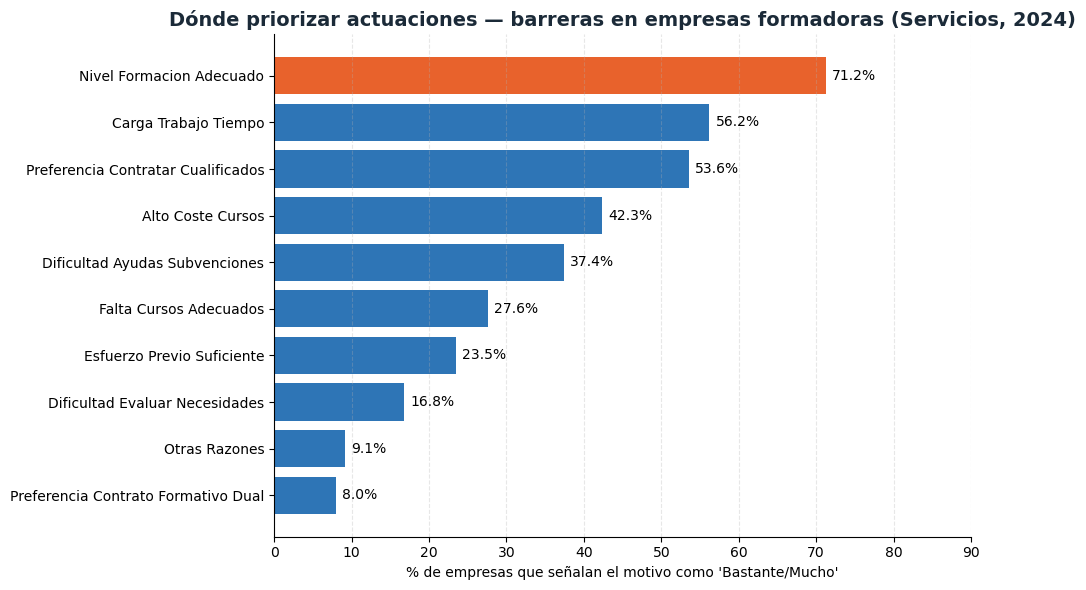

In [88]:
formadoras_orden = tabla_comparativa["Formadoras (%)"].sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colores_barras = [COLOR_DESTACADO if v == formadoras_orden.max() else COLOR_SECUNDARIO for v in formadoras_orden]
ax.barh(formadoras_orden.index.str.replace("_", " "), formadoras_orden.values, color=colores_barras)

ax.set_title(f"Dónde priorizar actuaciones — barreras en empresas formadoras (Servicios, {AÑO_REFERENCIA})",
             fontsize=14, fontweight="bold", color=COLOR_TITULO)
ax.set_xlabel("% de empresas que señalan el motivo como 'Bastante/Mucho'")
ax.set_xlim(0, 90)
ax.grid(axis="x", linestyle="--", alpha=0.3)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

for i, v in enumerate(formadoras_orden.values):
    ax.text(v + 0.8, i, f"{v:.1f}%", va="center", fontsize=10)

plt.tight_layout()
plt.show()

**Interpretación:** dado que RAPIDexpress desarrolla acciones formativas de forma habitual, el análisis se centra en las empresas formadoras. En este grupo, las principales barreras no están relacionadas con la falta de interés por la formación, sino con su implementación: la carga de trabajo y la falta de tiempo siguen siendo el principal obstáculo, mientras que el elevado coste de los cursos y las dificultades para acceder a ayudas también mantienen una presencia relevante.

### 5.1.1 Vista jerárquica: categorías y motivos (treemap)

Con 10 motivos es difícil retener de un vistazo cuál pesa más. Se agrupan en 4 categorías superiores — una clasificación **propia**, no un dato oficial de la EAL:

- **Percepción / Autosuficiencia**: la empresa considera que ya forma lo suficiente
- **Decisión estratégica de contratación**: resuelve la necesidad contratando ya cualificados
- **Barreras operativas internas**: la empresa puede actuar directamente (tiempo, evaluación de necesidades)
- **Barreras económicas / de oferta externa**: dependen del mercado (coste, oferta, ayudas)

In [89]:
MAPA_CATEGORIAS = {
    "Nivel_Formacion_Adecuado": "Percepción / Autosuficiencia",
    "Esfuerzo_Previo_Suficiente": "Percepción / Autosuficiencia",
    "Preferencia_Contratar_Cualificados": "Decisión estratégica de contratación",
    "Preferencia_Contrato_Formativo_Dual": "Decisión estratégica de contratación",
    "Carga_Trabajo_Tiempo": "Barreras operativas internas",
    "Dificultad_Evaluar_Necesidades": "Barreras operativas internas",
    "Alto_Coste_Cursos": "Barreras económicas / de oferta externa",
    "Falta_Cursos_Adecuados": "Barreras económicas / de oferta externa",
    "Dificultad_Ayudas_Subvenciones": "Barreras económicas / de oferta externa",
    "Otras_Razones": "Otras razones",
    "Cancelacion_COVID": "Otras razones",
}

datos_treemap = datos_hero.copy()
datos_treemap["categoria"] = datos_treemap["motivo"].map(MAPA_CATEGORIAS)
datos_treemap["motivo_corto"] = datos_treemap["motivo"].map(NOMBRES_MOTIVO_CORTO)

fig_treemap = px.treemap(
    datos_treemap,
    path=[px.Constant("Barreras a la formación"), "categoria", "motivo_corto"],
    values="bastante_mucho",
    color="categoria",
    color_discrete_sequence=px.colors.qualitative.Set2,
)
fig_treemap.update_traces(textinfo="label+value", texttemplate="%{label}<br>%{value:.1f}%")
fig_treemap.update_layout(
    title=f"Barreras a la formación por categoría — Empresas formadoras, Servicios {AÑO_REFERENCIA}",
    margin=dict(t=50, l=10, r=10, b=10),
)
fig_treemap.show()

**Interpretación:** el bloque más grande indica qué categoría domina en conjunto; dentro de él, el sub-bloque más grande señala el motivo concreto que más pesa.

### 5.1.2 ¿Qué barreras son más relevantes y cuáles crecen más?

Combina en un único gráfico dos preguntas distintas: **cuánto pesa hoy** cada barrera (punto, eje superior) y **cuánto ha variado relativamente** desde 2022 (barra, eje inferior). Una barrera puede tener un nivel bajo pero crecer muy rápido — o al revés, ser dominante pero estable. `Preferencia_Contrato_Formativo_Dual` se excluye por no tener dato en 2022 (sección 3.1).

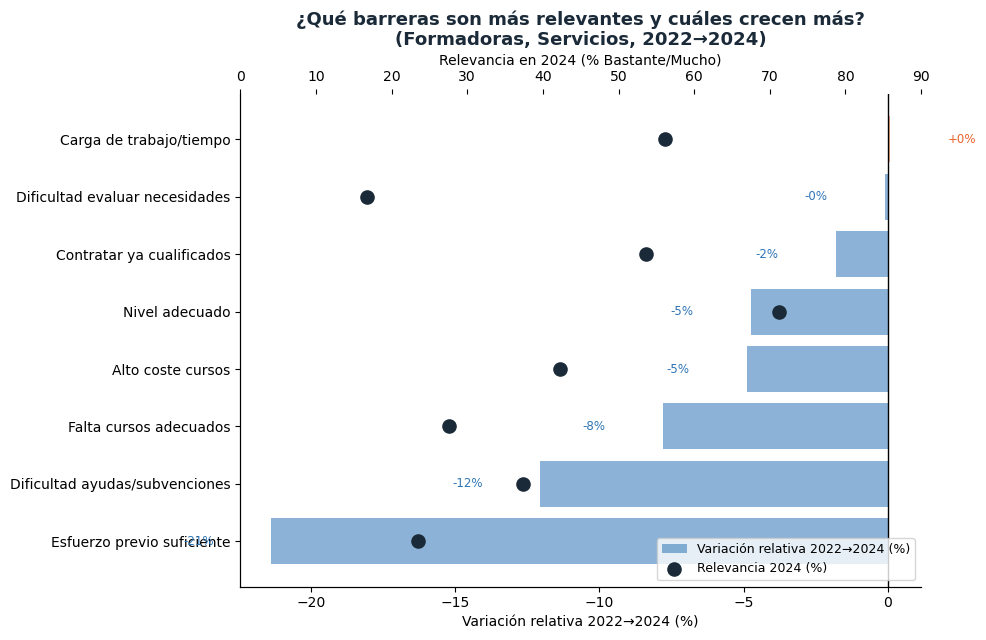

In [90]:
evolucion_nivel_crecimiento = (
    df_barreras[
        (df_barreras["anio"].isin([2022, AÑO_REFERENCIA]))
        & (df_barreras["ambito"] == "Servicios")
        & (df_barreras["tipo_empresa"] == "Formadoras")
    ]
    .pivot_table(index="motivo", columns="anio", values="bastante_mucho")
    .dropna()
)
evolucion_nivel_crecimiento["variacion_relativa_%"] = (
    (evolucion_nivel_crecimiento[AÑO_REFERENCIA] - evolucion_nivel_crecimiento[2022])
    / evolucion_nivel_crecimiento[2022] * 100
)
evolucion_nivel_crecimiento = evolucion_nivel_crecimiento.sort_values("variacion_relativa_%")

fig, ax1 = plt.subplots(figsize=(10, 6.5))
etiquetas = evolucion_nivel_crecimiento.index.map(lambda m: NOMBRES_MOTIVO_CORTO.get(m, m))
colores_barra = [COLOR_DESTACADO if v > 0 else COLOR_SECUNDARIO for v in evolucion_nivel_crecimiento["variacion_relativa_%"]]

ax1.barh(etiquetas, evolucion_nivel_crecimiento["variacion_relativa_%"], color=colores_barra, alpha=0.55,
         label="Variación relativa 2022→2024 (%)")
ax1.axvline(0, color="black", linewidth=1)
ax1.set_xlabel("Variación relativa 2022→2024 (%)")

ax2 = ax1.twiny()
ax2.scatter(evolucion_nivel_crecimiento[AÑO_REFERENCIA], etiquetas, color=COLOR_TITULO, s=90, zorder=5,
            label=f"Relevancia {AÑO_REFERENCIA} (%)")
ax2.set_xlabel(f"Relevancia en {AÑO_REFERENCIA} (% Bastante/Mucho)")
ax2.set_xlim(0, 90)

for i, (_, fila) in enumerate(evolucion_nivel_crecimiento.iterrows()):
    v = fila["variacion_relativa_%"]
    ax1.text(v + (2 if v >= 0 else -2), i, f"{v:+.0f}%", va="center",
              ha="left" if v >= 0 else "right", fontsize=8.5, color=colores_barra[i])

ax1.set_title("¿Qué barreras son más relevantes y cuáles crecen más?\n(Formadoras, Servicios, 2022→2024)",
              fontsize=13, fontweight="bold", color=COLOR_TITULO)
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="lower right", fontsize=9)
for spine in ["top", "right"]:
    ax1.spines[spine].set_visible(False)
    ax2.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

**Interpretación:** `Carga_Trabajo_Tiempo` combina el nivel más alto con una variación prácticamente nula — es la barrera más estable y dominante, no una moda pasajera. En el otro extremo, `Esfuerzo_Previo_Suficiente` cae con fuerza en términos relativos, aunque partía de un nivel más bajo.

### 5.2 Evolución por dimensión estratégica

Agregando los motivos en las 4 categorías de la sección 5.1.1, ¿qué dimensión domina y cómo se mueve en el tiempo? Solo se promedian motivos con dato en los 3 años (ver aviso 3.1); la categoría "Otras razones" se excluye por su tamaño reducido y menor relevancia interpretativa.

Motivos excluidos del promedio por categoría (sin dato en los 3 años): ['Preferencia_Contrato_Formativo_Dual']


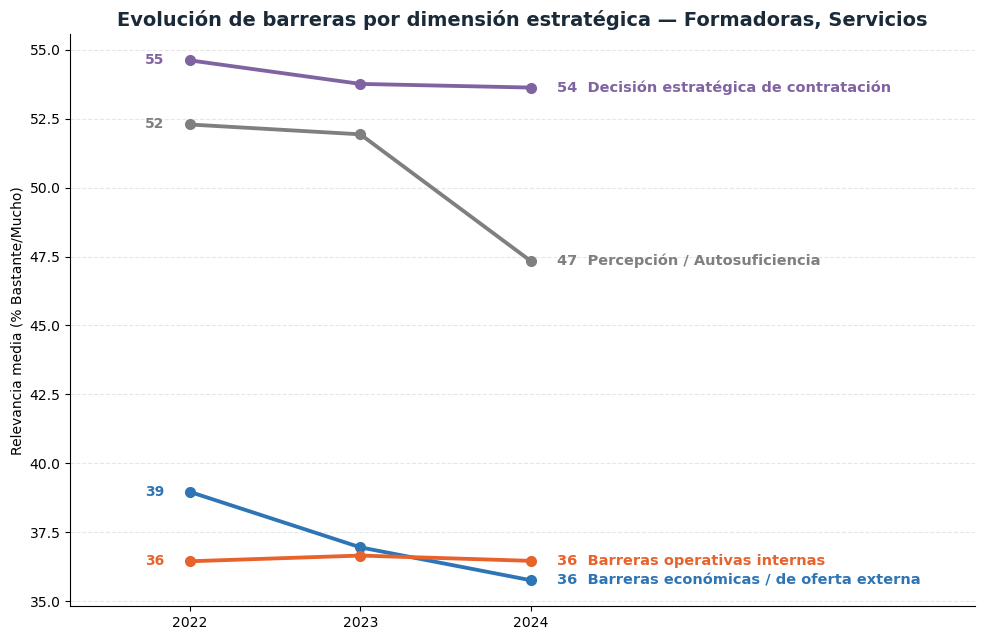

In [91]:
COLORES_CATEGORIA = {
    "Barreras operativas internas": COLOR_DESTACADO,
    "Barreras económicas / de oferta externa": COLOR_SECUNDARIO,
    "Decisión estratégica de contratación": "#8064A2",
    "Percepción / Autosuficiencia": "#7F7F7F",
}

datos_categoria = df_barreras[
    (df_barreras["ambito"] == "Servicios")
    & (df_barreras["tipo_empresa"] == "Formadoras")
    & (df_barreras["anio"].isin([2022, 2023, 2024]))
    & (~df_barreras["motivo"].isin(["Otras_Razones", "Cancelacion_COVID"]))
].copy()
datos_categoria["categoria"] = datos_categoria["motivo"].map(MAPA_CATEGORIAS)

# Solo motivos con dato en los 3 años, para que el promedio de cada categoría sea comparable
pivote_completo = datos_categoria.pivot_table(index="motivo", columns="anio", values="bastante_mucho")
motivos_completos = pivote_completo.dropna().index.tolist()
motivos_excluidos = pivote_completo[pivote_completo.isna().any(axis=1)].index.tolist()
if motivos_excluidos:
    print("Motivos excluidos del promedio por categoría (sin dato en los 3 años):", motivos_excluidos)

evolucion_categoria = (
    datos_categoria[datos_categoria["motivo"].isin(motivos_completos)]
    .groupby(["categoria", "anio"])["bastante_mucho"].mean()
    .unstack("anio")
)

fig, ax = plt.subplots(figsize=(10, 6.5))
for categoria, fila in evolucion_categoria.iterrows():
    color = COLORES_CATEGORIA.get(categoria, "#333333")
    ax.plot(fila.index, fila.values, marker="o", linewidth=2.75, color=color, markersize=7)
    ax.text(2021.85, fila[2022], f"{fila[2022]:.0f}", ha="right", va="center", fontsize=10, fontweight="bold", color=color)
    ax.text(2024.15, fila[2024], f"{fila[2024]:.0f}  {categoria}", ha="left", va="center", fontsize=10.5, fontweight="bold", color=color)

ax.set_xlim(2021.3, 2026.6)
ax.set_xticks([2022, 2023, 2024])
ax.set_ylabel("Relevancia media (% Bastante/Mucho)")
ax.set_title("Evolución de barreras por dimensión estratégica — Formadoras, Servicios", fontsize=14, fontweight="bold", color=COLOR_TITULO)
ax.grid(axis="y", linestyle="--", alpha=0.3)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

**Interpretación:** la "Decisión estratégica de contratación" es la dimensión con mayor peso medio y se mantiene estable — no es una barrera que esté emergiendo, es una preferencia estructural. Las "Barreras operativas internas" (tiempo, evaluación de necesidades) también se mantienen estables en segundo lugar; las "económicas" muestran un descenso más claro en el periodo.

### 5.3 Evolución temporal y significación por motivo (2022-2024)

En vez de separar "cómo evoluciona" de "es fiable ese cambio" en dos gráficos distintos, se combinan aquí: el **trazo grueso y sólido** indica un cambio estadísticamente fiable entre dos años consecutivos; el **trazo fino y discontinuo**, un cambio que podría deberse solo al azar de la muestra.

**<span style="color:#2E75B6;">¿Por qué este test y no otro?</span>** Necesitamos responder si un cambio concreto entre dos años, para un motivo concreto, es fiable — el test de diferencia de dos proporciones es la técnica estándar para esa pregunta. Su límite conocido (la `n` viene de una tabla agregada del sector, no del subgrupo exacto formadoras/no formadoras, y no ajusta por el diseño muestral estratificado de la EAL) se documenta explícitamente, en vez de ocultarlo.

In [92]:
# Tamaño de muestra por año y ámbito, extraído del Informe Metodológico Estandarizado de la EAL
# (tabla "nº de empresas en la muestra", por tramo de tamaño y por actividad económica).
# Servicios = suma de los subsectores G a S de esa tabla.
N_MUESTRA = {
    ("Servicios", 2022): 6266,
    ("Servicios", 2023): 6107,
    ("Servicios", 2024): 5963,
    ("Total_Nacional", 2022): 10224,
    ("Total_Nacional", 2023): 9982,
    ("Total_Nacional", 2024): 9767,
}


def test_diferencia_proporciones(porcentaje_a, n_a, porcentaje_b, n_b):
    '''Test Z de diferencia de dos proporciones. Devuelve el p-valor: cuanto más
    bajo, menos probable que la diferencia observada se deba solo al azar de la
    muestra. Sirve tanto para comparar dos años (misma población, distinta
    edición) como dos grupos (mismo año, distinta población).'''
    conteos = [round(porcentaje_a * n_a / 100), round(porcentaje_b * n_b / 100)]
    tamanios = [n_a, n_b]
    _, p_valor = proportions_ztest(conteos, tamanios)
    return p_valor


evolucion = (
    df_barreras[(df_barreras["anio"].isin([2022, 2023, 2024])) & (df_barreras["ambito"] == "Servicios")]
    .pivot_table(index=["tipo_empresa", "motivo"], columns="anio", values="bastante_mucho")
)
evolucion["variacion_pp"] = evolucion[2024] - evolucion[2022]
evolucion["variacion_relativa_%"] = (evolucion[2024] - evolucion[2022]) / evolucion[2022] * 100

resultados_significacion = []
for (tipo_empresa, motivo), fila in evolucion.iterrows():
    for anio_inicial, anio_final in [(2022, 2023), (2023, 2024)]:
        p_inicial, p_final = fila.get(anio_inicial), fila.get(anio_final)
        if pd.isna(p_inicial) or pd.isna(p_final):
            continue
        n_inicial = N_MUESTRA[("Servicios", anio_inicial)]
        n_final = N_MUESTRA[("Servicios", anio_final)]
        p_valor = test_diferencia_proporciones(p_inicial, n_inicial, p_final, n_final)
        resultados_significacion.append({
            "tipo_empresa": tipo_empresa, "motivo": motivo, "periodo": f"{anio_inicial}→{anio_final}",
            "%_inicio": round(p_inicial, 1), "%_fin": round(p_final, 1),
            "variacion_pp": round(p_final - p_inicial, 1), "p_valor": round(p_valor, 4),
            "¿Cambio_fiable? (p<0.05)": "Sí" if p_valor < 0.05 else "No",
        })

df_significacion = pd.DataFrame(resultados_significacion).sort_values("p_valor")

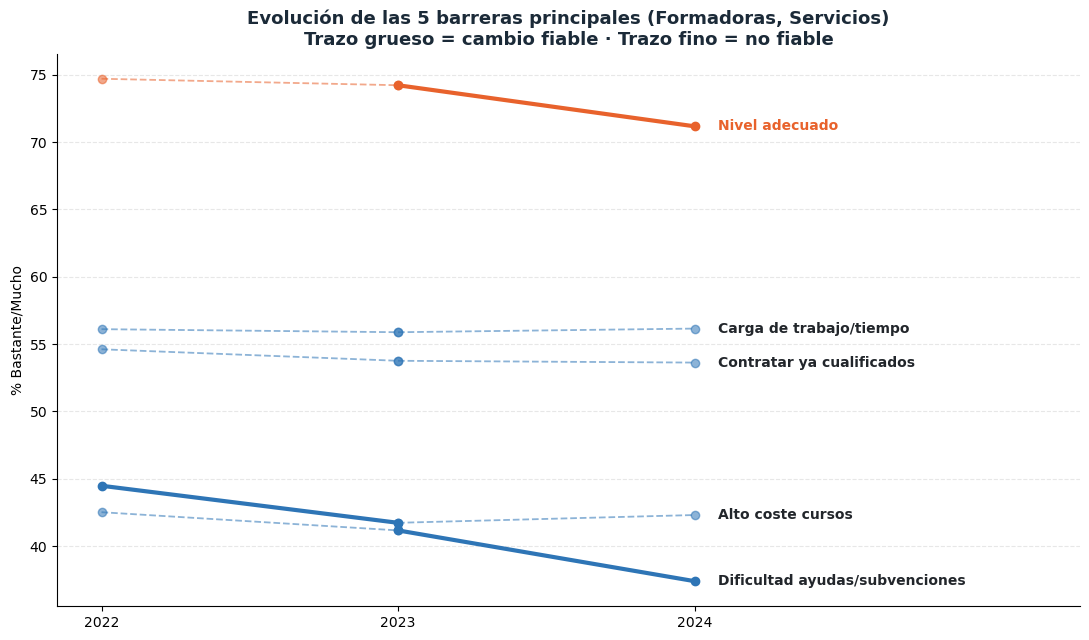

In [93]:
fig, ax = plt.subplots(figsize=(11, 6.5))

for motivo in top5_motivos:
    serie = (
        df_barreras[
            (df_barreras["ambito"] == "Servicios") & (df_barreras["tipo_empresa"] == "Formadoras")
            & (df_barreras["motivo"] == motivo) & (df_barreras["anio"].isin([2022, 2023, 2024]))
        ]
        .set_index("anio")["bastante_mucho"].reindex([2022, 2023, 2024])
    )

    for anio_a, anio_b in [(2022, 2023), (2023, 2024)]:
        fiable = df_significacion[
            (df_significacion["tipo_empresa"] == "Formadoras")
            & (df_significacion["motivo"] == motivo)
            & (df_significacion["periodo"] == f"{anio_a}→{anio_b}")
        ]
        es_fiable = not fiable.empty and fiable.iloc[0]["¿Cambio_fiable? (p<0.05)"] == "Sí"
        ax.plot(
            [anio_a, anio_b], [serie[anio_a], serie[anio_b]],
            color=COLOR_SECUNDARIO if motivo != motivo_principal["motivo"] else COLOR_DESTACADO,
            linewidth=3 if es_fiable else 1.3,
            linestyle="-" if es_fiable else "--",
            alpha=1.0 if es_fiable else 0.55,
            marker="o", markersize=6,
        )

    nombre = NOMBRES_MOTIVO_CORTO.get(motivo, motivo)
    ax.text(2024.08, serie[2024], nombre, va="center", fontsize=10, fontweight="bold",
            color=COLOR_DESTACADO if motivo == motivo_principal["motivo"] else COLOR_TEXTO)

ax.set_xlim(2021.85, 2025.3)
ax.set_xticks([2022, 2023, 2024])
ax.set_ylabel("% Bastante/Mucho")
ax.set_title("Evolución de las 5 barreras principales (Formadoras, Servicios)\nTrazo grueso = cambio fiable · Trazo fino = no fiable",
             fontsize=13, fontweight="bold", color=COLOR_TITULO)
ax.grid(axis="y", linestyle="--", alpha=0.3)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

**Interpretación:** solo los tramos con trazo grueso se pueden defender como una tendencia real; los tramos discontinuos muestran variación en el porcentaje, pero no hay evidencia suficiente para descartar que sea ruido de muestra.

In [94]:
df_significacion

,tipo_empresa,motivo,periodo,%_inicio,%_fin,variacion_pp,p_valor,¿Cambio_fiable? (p<0.05)
18,No_formadoras,Alto_Coste_Cursos,2022→2023,35.7,40.9,5.1,0.0000,Sí
23,No_formadoras,Dificultad_Ayudas_Subvenciones,2023→2024,41.0,33.2,-7.8,0.0000,Sí
25,No_formadoras,Dificultad_Evaluar_Necesidades,2023→2024,23.6,20.5,-3.1,0.0000,Sí
26,No_formadoras,Esfuerzo_Previo_Suficiente,2022→2023,29.1,25.1,-4.0,0.0000,Sí
27,No_formadoras,Esfuerzo_Previo_Suficiente,2023→2024,25.1,21.7,-3.4,0.0000,Sí
9,Formadoras,Esfuerzo_Previo_Suficiente,2023→2024,29.6,23.5,-6.2,0.0000,Sí
22,No_formadoras,Dificultad_Ayudas_Subvenciones,2022→2023,37.3,41.0,3.7,0.0000,Sí
29,No_formadoras,Falta_Cursos_Adecuados,2023→2024,32.6,25.6,-7.0,0.0000,Sí
31,No_formadoras,Nivel_Formacion_Adecuado,2023→2024,72.7,80.8,8.1,0.0000,Sí
5,Formadoras,Dificultad_Ayudas_Subvenciones,2023→2024,41.2,37.4,-3.8,0.0000,Sí


La columna `¿Cambio_fiable?` distingue, para los 10 motivos y ambos grupos, cuáles cambios se pueden defender como una tendencia real. El gráfico anterior visualiza esto para las 5 barreras principales de empresas formadoras; esta tabla cubre el resto de combinaciones.

---
## 6. Servicios (proxy) vs. Total nacional

Comprueba si el sector Servicios se comporta distinto de la media española — y si esa diferencia es estadísticamente fiable, no solo un par de puntos porcentuales. Aquí sí se dispone de la `n` correcta para cada lado de la comparación (Servicios y Total Nacional, sección 5.3), así que el test es más sólido que en la sección 7.

In [95]:
comparacion_ambito = (
    df_barreras[(df_barreras["anio"] == AÑO_REFERENCIA) & (df_barreras["tipo_empresa"] == "Formadoras")]
    .pivot_table(index="motivo", columns="ambito", values="bastante_mucho")
)
comparacion_ambito["diferencia_pp"] = comparacion_ambito["Servicios"] - comparacion_ambito["Total_Nacional"]

n_servicios = N_MUESTRA[("Servicios", AÑO_REFERENCIA)]
n_total = N_MUESTRA[("Total_Nacional", AÑO_REFERENCIA)]
comparacion_ambito["p_valor"] = comparacion_ambito.apply(
    lambda fila: test_diferencia_proporciones(fila["Servicios"], n_servicios, fila["Total_Nacional"], n_total),
    axis=1,
)
comparacion_ambito["¿Diferencia_fiable?"] = np.where(comparacion_ambito["p_valor"] < 0.05, "Sí", "No")
comparacion_ambito.round(4).sort_values("diferencia_pp", key=abs, ascending=False)

ambito,Servicios,Total_Nacional,diferencia_pp,p_valor,¿Diferencia_fiable?
motivo,,,,,
Esfuerzo_Previo_Suficiente,23.487,25.122,-1.635,0.0211,Sí
Preferencia_Contratar_Cualificados,53.631,52.362,1.269,0.1214,No
Falta_Cursos_Adecuados,27.563,28.102,-0.539,0.4681,No
Alto_Coste_Cursos,42.310,41.786,0.524,0.5156,No
Nivel_Formacion_Adecuado,71.178,71.489,-0.311,0.6731,No
Carga_Trabajo_Tiempo,56.156,56.387,-0.231,0.7866,No
Preferencia_Contrato_Formativo_Dual,8.048,8.212,-0.164,0.7192,No
Dificultad_Ayudas_Subvenciones,37.398,37.252,0.146,0.8509,No
Otras_Razones,9.115,8.973,0.142,0.7438,No


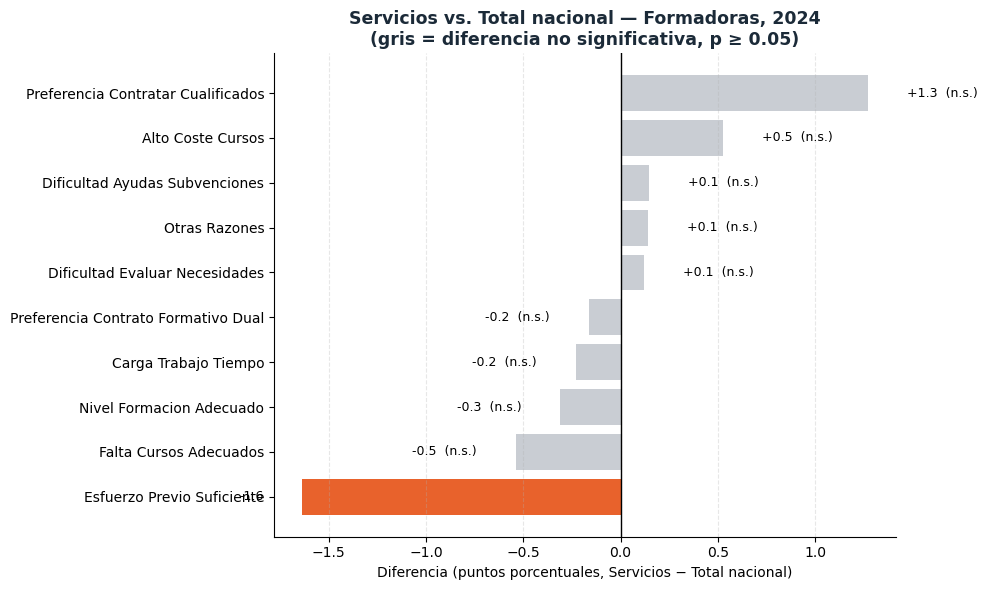

In [96]:
dif_ambito = comparacion_ambito.sort_values("diferencia_pp")

fig, ax = plt.subplots(figsize=(10, 6))
colores = [
    (COLOR_SECUNDARIO if v > 0 else COLOR_DESTACADO) if fiable == "Sí" else COLOR_NO_SIG
    for v, fiable in zip(dif_ambito["diferencia_pp"], dif_ambito["¿Diferencia_fiable?"])
]
ax.barh(dif_ambito.index.str.replace("_", " "), dif_ambito["diferencia_pp"], color=colores)
ax.axvline(0, color="black", linewidth=1)

ax.set_title(f"Servicios vs. Total nacional — Formadoras, {AÑO_REFERENCIA}\n(gris = diferencia no significativa, p ≥ 0.05)",
             fontsize=12.5, fontweight="bold", color=COLOR_TITULO)
ax.set_xlabel("Diferencia (puntos porcentuales, Servicios − Total nacional)")
ax.grid(axis="x", linestyle="--", alpha=0.3)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

for i, (v, fiable) in enumerate(zip(dif_ambito["diferencia_pp"], dif_ambito["¿Diferencia_fiable?"])):
    etiqueta = f"{v:+.1f}" + ("" if fiable == "Sí" else "  (n.s.)")
    ax.text(v + (0.2 if v >= 0 else -0.2), i, etiqueta, va="center", ha="left" if v >= 0 else "right", fontsize=9)

plt.tight_layout()
plt.show()

**Conclusión:** casi todas las diferencias `Servicios − Total_Nacional` no son estadísticamente fiables (barras grises) — el proxy es sólido, con respaldo estadístico y no solo por inspección visual de que "los puntos son pocos".

---
## 7. Diferencia de peso en barreras respecto a empresas no formadoras

Año de análisis: 2024 (más reciente).

**<span style="color:orange;">Aviso sobre la prueba:</span>** a diferencia de la sección 6, aquí **no** se dispone de la `n` real de cada subgrupo (formadoras y no formadoras por separado dentro de Servicios) — se aproxima usando la `n` total del sector para ambos, que es **mayor** que la de cada subgrupo real. Esto tendirá **sobrestimar la significación** (hace parecer "fiables" diferencias que con el tamaño de muestra real podrían no serlo). Los resultados de esta sección deben leerse como orientativos.

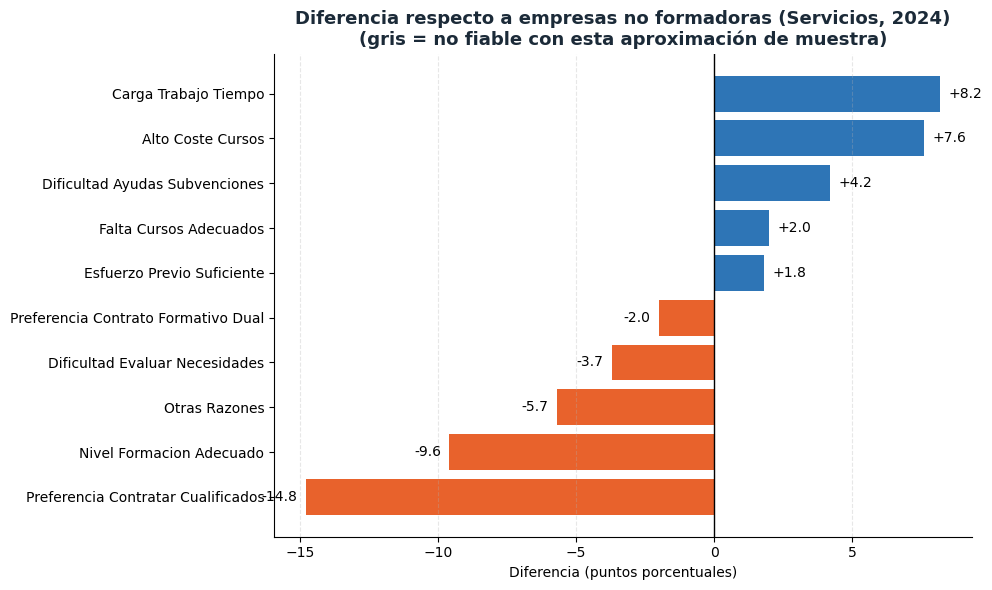

In [97]:
n_servicios_total = N_MUESTRA[("Servicios", AÑO_REFERENCIA)]
tabla_comparativa["p_valor"] = tabla_comparativa.apply(
    lambda fila: test_diferencia_proporciones(
        fila["Formadoras (%)"], n_servicios_total, fila["No formadoras (%)"], n_servicios_total
    ),
    axis=1,
)
tabla_comparativa["¿Diferencia_fiable?"] = np.where(tabla_comparativa["p_valor"] < 0.05, "Sí", "No")

fig, ax = plt.subplots(figsize=(10, 6))

dif = tabla_comparativa["Diferencia (pp)"].sort_values()
fiabilidad = tabla_comparativa.loc[dif.index, "¿Diferencia_fiable?"]
colores_dif = [
    (COLOR_SECUNDARIO if v > 0 else COLOR_DESTACADO) if fiable == "Sí" else COLOR_NO_SIG
    for v, fiable in zip(dif, fiabilidad)
]

ax.barh(dif.index.str.replace("_", " "), dif.values, color=colores_dif)
ax.axvline(0, color="black", linewidth=1)

ax.set_title(f"Diferencia respecto a empresas no formadoras (Servicios, {AÑO_REFERENCIA})\n(gris = no fiable con esta aproximación de muestra)",
             fontsize=13, fontweight="bold", color=COLOR_TITULO)
ax.set_xlabel("Diferencia (puntos porcentuales)")
ax.grid(axis="x", linestyle="--", alpha=0.3)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

for i, v in enumerate(dif.values):
    if v >= 0:
        ax.text(v + 0.3, i, f"+{v:.1f}", va="center")
    else:
        ax.text(v - 0.3, i, f"{v:.1f}", va="center", ha="right")

plt.tight_layout()
plt.show()

El benchmark muestra que las empresas formadoras y las no formadoras presentan perfiles de barreras diferentes. Las formadoras señalan con mayor frecuencia obstáculos relacionados con la implantación de la formación (carga de trabajo, coste, acceso a ayudas); las no formadoras justifican la ausencia de formación sobre todo por preferir contratar personal ya cualificado o considerar suficiente el nivel formativo de su plantilla — recordando el aviso anterior sobre la fiabilidad exacta de esta comparación concreta.

---
## 8. Conclusiones

### Principales hallazgos

- **<span style="color:orange;">Carga de trabajo/tiempo</span>** es la segunda barrera en magnitud entre empresas formadoras (56,2% en 2024, sección 5.1), y la sección 5.3 confirma que **no ha cambiado de forma fiable** entre 2022-2023 (p=0,80) ni 2023-2024 (p=0,76) - es una barrera estable, no una tendencia puntual.

- De los motivos con cambio significativo 2022 ->2023 (sección 5.3), tres bajaron de forma fiable para empresas formadoras: **Alto_Coste_Cursos** (-2,8 pp, p=0,0021), **Nivel_Formacion_Adecuado** (-3,0 pp, p=0,0002) y **Falta_Cursos_Adecuados** (-1,9 pp, p=0,0174). **Ningún motivo tuvo un cambio fiable entre 2023 y 2024** - la situación se estabilizó tras 2023.
- El proxy Servicios es estadísticamente sólido (sección 6): de 10 motivos comparados con el Total Nacional, solo **Esfuerzo_Previo_Suficiente** mostró una diferencia fiable (p=0,0211); el resto no son distinguibles del total nacional.
- El benchmark Formadoras vs. No formadoras (sección 7) muestra diferencias grandes — **Preferencia_Contratar_Cualificados** (-14,8 pp) y **Nivel_Formacion_Adecuado** (-9,6 pp) más altas en no formadoras;   **Carga_Trabajo_Tiempo** (+8,2 pp) y **Alto_Coste_Cursos** (+7,6 pp) más altas en formadoras - con la precaución ya indicada sobre la fiabilidad de este test en concreto.  

### Recomendaciones

**1. Formación flexible para no competir con la carga de trabajo**  
*justificación:* "Carga de trabajo/tiempo" es la segunda barrera en peso (56,2%) y se mantiene **sin cambio fiable** en 2022-2024 (sección 5.3) — no va a remitir por sí sola.  
*Acciones concretas:* microformación en sesiones cortas integradas en la jornada, formación en el puesto de trabajo, rotación de turnos.  

**2. Aprovechar la mejora ya lograda en coste y oferta de cursos, sin darla por definitiva**  
*justificación:* "Alto_Coste_Cursos" y "Falta_Cursos_Adecuados" bajaron de forma fiable en 2022-2023, pero **no siguieron bajando** en 2023-2024 (sección 5.3) — la mejora podría haberse estancado.  
*Acción concreta:* revisar si las medidas que ayudaron en 2022-2023 se han mantenido activas.
  
**3. Diferenciarse activamente del perfil de las empresas no formadoras**  
*justificación:* el benchmark (sección 7) muestra que las no formadoras se apoyan mucho más en preferir contratar ya cualificados (-14,8 pp) - un enfoque distinto al de RAPIDexpress.  
*Acción concreta:* mantener y comunicar la ventaja competitiva de formar, en vez de tratar la carga de trabajo como motivo para reducir el esfuerzo formativo.  

**4. Usar el proxy sectorial (Servicios) con confianza respaldada estadísticamente**  
*justificación:* 9 de 10 motivos no muestran diferencia fiable entre Servicios y el Total Nacional (sección 6).

### Limitaciones

- El sector Servicios es un proxy de "Transporte y almacenamiento", no el dato exacto del sector.
- `Preferencia_Contrato_Formativo_Dual` no tiene dato en 2022 para formadoras; se excluye de los promedios que requieren los 3 años.
- La `n` de la sección 7 aproxima el mismo tamaño de muestra para formadoras y no formadoras, lo que probablemente **sobrestima** la significación de esa comparación.
- Ningún test ajusta por el diseño muestral estratificado de la EAL.